<a href="https://www.kaggle.com/code/amarnathdj/audio-processing?scriptVersionId=329443056" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [23]:
#clean csvs

import pandas as pd
import numpy as np
import re

csv_path = "/kaggle/working/november_2024_clean1.csv"

# =====================================================
# LOAD
# =====================================================

df = pd.read_csv(csv_path)

print("Original shape:", df.shape)

# Remove index columns
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# =====================================================
# FIND COLUMNS
# =====================================================

time_col = None
rain_col = None

for col in df.columns:

    if "time" in col.lower():
        time_col = col

    if "rain" in col.lower():
        rain_col = col

print("Time column:", time_col)
print("Rain column:", rain_col)

# =====================================================
# CONVERT RAINFALL
# =====================================================

def convert_to_mm(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    # Extract first number
    match = re.search(r"[\d.]+", value)

    if match is None:
        return np.nan

    num = float(match.group())

    if "µm" in value:
        return num / 1000

    return num

# =====================================================
# STANDARDIZE
# =====================================================

df = df.rename(columns={
    time_col: "timestamp",
    rain_col: "rainfall_mm"
})

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="mixed",
    errors="coerce"
)

df["rainfall_mm"] = df["rainfall_mm"].apply(
    convert_to_mm
)

# =====================================================
# CHECK BEFORE DROPPING
# =====================================================

print("\nNaN timestamps:",
      df["timestamp"].isna().sum())

print("NaN rainfall:",
      df["rainfall_mm"].isna().sum())

# =====================================================
# CLEAN
# =====================================================

df = df.dropna(
    subset=["timestamp", "rainfall_mm"]
)

df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

# =====================================================
# SAVE
# =====================================================

output_path = "/kaggle/working/November_2024_clean.csv"

df.to_csv(
    output_path,
    index=False
)

print("\nFinal shape:", df.shape)
print("\nSaved to:")
print(output_path)

print("\nHead:")
print(df.head())

Original shape: (14382, 3)
Time column: time
Rain column: rainfall

NaN timestamps: 0
NaN rainfall: 0

Final shape: (14382, 2)

Saved to:
/kaggle/working/November_2024_clean.csv

Head:
                   timestamp  rainfall_mm
0 2024-11-01 00:00:25.801603          0.0
1 2024-11-01 00:03:25.801603          0.0
2 2024-11-01 00:06:25.801605          0.0
3 2024-11-01 00:09:25.801603          0.0
4 2024-11-01 00:12:25.801604          0.0


In [ ]:
#create wave timestamp dataframe

import os
import pandas as pd
from datetime import datetime

audio_root = "/kaggle/input/datasets/amarnathdj/nov-2024-rainfall-data"

audio_records = []

for root, dirs, files in os.walk(audio_root):

    for f in files:

        if not f.endswith(".wav"):
            continue

        try:
            ts = datetime.strptime(
                f.replace(".wav", ""),
                "%Y_%m_%d_%H_%M_%S_%f"
            )

            audio_records.append({
                "audio_path": os.path.join(root, f),
                "audio_time": ts
            })

        except:
            pass

audio_df = pd.DataFrame(audio_records)

print(audio_df.head())
print("Total wavs:", len(audio_df))

In [ ]:
#load csv
labels_df = pd.read_csv(
    "/kaggle/working/November_2024_clean.csv"
)

labels_df["timestamp"] = pd.to_datetime(
    labels_df["timestamp"],
    format="mixed"
)

print(labels_df.head())

# Optional sanity check
print(labels_df["timestamp"].min())
print(labels_df["timestamp"].max())


In [37]:
print("Hi")

Hi


In [ ]:
#find wavs belonging to each label
from datetime import timedelta

aligned_samples = []

for _, row in labels_df.iterrows():

    label_time = row["timestamp"]

    start = label_time - timedelta(seconds=90)
    end   = label_time + timedelta(seconds=90)

    matching_wavs = audio_df[
        (audio_df["audio_time"] >= start) &
        (audio_df["audio_time"] <= end)
    ]

    aligned_samples.append({
        "timestamp": label_time,
        "rainfall_mm": row["rainfall_mm"],
        "wav_count": len(matching_wavs),
        "wav_files": matching_wavs["audio_path"].tolist()
    })

aligned_df = pd.DataFrame(aligned_samples)

aligned_df.head()

In [ ]:
#validate

print(
    aligned_df["wav_count"]
    .describe()
)

print(
    aligned_df["wav_count"]
    .value_counts()
    .sort_index()
)

In [25]:
#inspect wav spacing

audio_df = audio_df.sort_values("audio_time")

print(
    audio_df["audio_time"]
    .diff()
    .value_counts()
    .head(20)
)

audio_time
0 days 00:00:10.010082    17
0 days 00:00:10.009353    14
0 days 00:00:10.009809    14
0 days 00:00:10.009434    14
0 days 00:00:10.009559    13
0 days 00:00:10.011185    13
0 days 00:00:10.010138    13
0 days 00:00:10.010424    13
0 days 00:00:10.009861    13
0 days 00:00:10.009259    13
0 days 00:00:10.009122    12
0 days 00:00:10.011236    12
0 days 00:00:10.009185    12
0 days 00:00:10.011044    12
0 days 00:00:10.009191    12
0 days 00:00:10.010581    12
0 days 00:00:10.009715    12
0 days 00:00:10.010362    12
0 days 00:00:10.009218    12
0 days 00:00:10.009747    12
Name: count, dtype: int64


In [26]:
#remove invalid samples

aligned_df = aligned_df[
    aligned_df["wav_count"].between(17,18)
]

aligned_df = aligned_df.dropna(
    subset=["rainfall_mm"]
)

aligned_df = aligned_df.reset_index(drop=True)
month_name = "november_2024"
aligned_df.to_pickle(f"{month_name}_aligned_dataset.pkl")

In [ ]:
print(aligned_df[aligned_df["wav_count"] < 17])

In [3]:
#inspect pickle files

df = pd.read_pickle("/kaggle/input/datasets/amarnathdj/aligned-data/pickle files/april_2024_aligned_dataset.pkl")

print(df.head())

                   timestamp  rainfall_mm  wav_count  \
0 2024-04-11 22:20:59.757439          0.0         17   
1 2024-04-11 22:21:09.757439          0.0         17   
2 2024-04-11 22:21:19.757438          0.0         17   
3 2024-04-11 22:21:29.757440          0.0         18   
4 2024-04-11 22:21:39.757440          0.0         18   

                                           wav_files  
0  [/kaggle/input/datasets/amarnathdj/april-2024-...  
1  [/kaggle/input/datasets/amarnathdj/april-2024-...  
2  [/kaggle/input/datasets/amarnathdj/april-2024-...  
3  [/kaggle/input/datasets/amarnathdj/april-2024-...  
4  [/kaggle/input/datasets/amarnathdj/april-2024-...  


In [2]:
#check wav file description

print(df["wav_count"].describe())

print(df["wav_count"].value_counts().sort_index())

NameError: name 'df' is not defined

In [4]:
#percentage of 0 values

print(df["rainfall_mm"].describe())

print(
    (df["rainfall_mm"] == 0).mean()
)

count    326.000000
mean       0.211656
std        0.790863
min        0.000000
25%        0.000000
50%        0.000000
75%        0.200000
max        9.000000
Name: rainfall_mm, dtype: float64
0.6625766871165644


In [6]:
#check wav file type

row = df.iloc[0]

print(type(row["wav_files"]))

print(row["wav_files"])

<class 'list'>
['/kaggle/input/datasets/amarnathdj/april-2024-rainfall-data/2024_04_11/2024_04_11_22_20_10_340487.wav', '/kaggle/input/datasets/amarnathdj/april-2024-rainfall-data/2024_04_11/2024_04_11_22_21_01_206302.wav', '/kaggle/input/datasets/amarnathdj/april-2024-rainfall-data/2024_04_11/2024_04_11_22_20_30_686197.wav', '/kaggle/input/datasets/amarnathdj/april-2024-rainfall-data/2024_04_11/2024_04_11_22_20_20_513940.wav', '/kaggle/input/datasets/amarnathdj/april-2024-rainfall-data/2024_04_11/2024_04_11_22_20_40_859258.wav', '/kaggle/input/datasets/amarnathdj/april-2024-rainfall-data/2024_04_11/2024_04_11_22_22_22_586632.wav', '/kaggle/input/datasets/amarnathdj/april-2024-rainfall-data/2024_04_11/2024_04_11_22_21_11_377146.wav', '/kaggle/input/datasets/amarnathdj/april-2024-rainfall-data/2024_04_11/2024_04_11_22_21_31_724199.wav', '/kaggle/input/datasets/amarnathdj/april-2024-rainfall-data/2024_04_11/2024_04_11_22_22_12_413496.wav', '/kaggle/input/datasets/amarnathdj/april-2024-ra

In [7]:
from datetime import datetime
import os

files = df.iloc[0]["wav_files"]

times = []

for f in files:
    name = os.path.basename(f).replace(".wav","")
    t = datetime.strptime(
        name,
        "%Y_%m_%d_%H_%M_%S_%f"
    )
    times.append(t)

print(times == sorted(times))

False


In [8]:
#sorting function

from datetime import datetime
import os

def sort_wavs(wav_list):

    return sorted(
        wav_list,
        key=lambda x: datetime.strptime(
            os.path.basename(x).replace(".wav",""),
            "%Y_%m_%d_%H_%M_%S_%f"
        )
    )

In [9]:
import librosa

files = sort_wavs(df.iloc[0]["wav_files"])

total_seconds = 0

for f in files:
    y, sr = librosa.load(f, sr=None)
    total_seconds += len(y) / sr

print(total_seconds)

KeyboardInterrupt: 

In [ ]:
#rainfall samples

print(len(df))

In [ ]:
#rainfall distribution

print(df["rainfall_mm"].describe())

print(
    df["rainfall_mm"].value_counts().head(20)
)

In [52]:
#rainy windows

rain = (df["rainfall_mm"] > 0).sum()
dry = (df["rainfall_mm"] == 0).sum()

print("Rain:", rain)
print("Dry :", dry)
print("Rain %:", rain/len(df)*100)

Rain: 110
Dry : 216
Rain %: 33.74233128834356


In [10]:
#combine the pickle files

import pandas as pd
import glob

files = glob.glob("/kaggle/input/datasets/amarnathdj/aligned-data/pickle files/*.pkl", recursive=True)

dfs = []

for f in files:
    df = pd.read_pickle(f)
    dfs.append(df)

master_df = pd.concat(dfs, ignore_index=True)

print(master_df.shape)

(28657, 4)


In [11]:
print(master_df.columns.tolist())

['timestamp', 'rainfall_mm', 'wav_count', 'wav_files']


In [12]:
#missing values

print(master_df.isnull().sum())

timestamp      0
rainfall_mm    0
wav_count      0
wav_files      0
dtype: int64


In [13]:
#audio coverage

print(master_df["wav_count"].describe())
print(master_df["wav_count"].value_counts().sort_index())

count    28657.000000
mean        17.577171
std          4.236886
min         17.000000
25%         17.000000
50%         17.000000
75%         17.000000
max         59.000000
Name: wav_count, dtype: float64
wav_count
17    24641
18     3699
57      164
58      145
59        8
Name: count, dtype: int64


In [14]:
#rainfall distribution

print(master_df["rainfall_mm"].describe())



count    28657.000000
mean         0.420066
std         13.412653
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        655.330000
Name: rainfall_mm, dtype: float64


In [15]:
#percentage of no rain samples

no_rain_pct = (master_df["rainfall_mm"] == 0).mean() * 100
print(f"No rain: {no_rain_pct:.2f}%")

No rain: 75.55%


In [16]:
#classifying audios

master_df["audio_type"] = master_df["wav_count"].apply(
    lambda x: "3s" if x > 30 else "10s"
)

print(master_df["audio_type"].value_counts())

audio_type
10s    28340
3s       317
Name: count, dtype: int64


In [17]:
import pandas as pd
import glob
import os

files = glob.glob("/kaggle/input/datasets/amarnathdj/aligned-data/pickle files/*.pkl")

dfs = []

for f in files:
    df = pd.read_pickle(f)

    # store source file name
    df["source_pickle"] = os.path.basename(f)

    dfs.append(df)

master_df = pd.concat(dfs, ignore_index=True)

In [18]:
three_sec = master_df[master_df["wav_count"] > 30]

In [19]:
print(three_sec["source_pickle"].value_counts())

source_pickle
december_2023_aligned_dataset.pkl    269
january_2024_aligned_dataset.pkl      48
Name: count, dtype: int64


In [20]:
master_df["rainfall_mm"].describe()

master_df["rainfall_mm"].value_counts().sort_index()

rainfall_mm
0.00      21651
0.01          4
0.02          4
0.03          5
0.04          4
          ...  
655.26        1
655.28        1
655.30        1
655.32        3
655.33        1
Name: count, Length: 258, dtype: int64

In [21]:
master_df["rainfall_mm"].describe()

count    28657.000000
mean         0.420066
std         13.412653
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        655.330000
Name: rainfall_mm, dtype: float64

In [22]:
master_df.sort_values("rainfall_mm").tail(20)

,timestamp,rainfall_mm,wav_count,wav_files,source_pickle
5194,2024-05-26 06:15:03,11.00,18,[/kaggle/input/datasets/amarnathdj/may-2024-ra...,may_2024_aligned_dataset.pkl
4997,2024-05-17 10:29:07,11.60,17,[/kaggle/input/datasets/amarnathdj/may-2024-ra...,may_2024_aligned_dataset.pkl
5085,2024-05-20 09:40:43,13.00,18,[/kaggle/input/datasets/amarnathdj/may-2024-ra...,may_2024_aligned_dataset.pkl
4960,2024-05-11 17:21:07,13.20,17,[/kaggle/input/datasets/amarnathdj/may-2024-ra...,may_2024_aligned_dataset.pkl
5114,2024-05-21 16:04:31,13.80,18,[/kaggle/input/datasets/amarnathdj/may-2024-ra...,may_2024_aligned_dataset.pkl
4998,2024-05-17 10:32:07,14.20,18,[/kaggle/input/datasets/amarnathdj/may-2024-ra...,may_2024_aligned_dataset.pkl
4995,2024-05-17 10:23:07,19.20,17,[/kaggle/input/datasets/amarnathdj/may-2024-ra...,may_2024_aligned_dataset.pkl
4996,2024-05-17 10:26:07,21.60,18,[/kaggle/input/datasets/amarnathdj/may-2024-ra...,may_2024_aligned_dataset.pkl
24074,2025-10-27 12:22:05,655.09,17,[/kaggle/input/datasets/amarnathdj/oct-2025-ra...,october_2025_aligned_dataset.pkl
24082,2025-10-27 16:46:53,655.15,17,[/kaggle/input/datasets/amarnathdj/oct-2025-ra...,october_2025_aligned_dataset.pkl


In [23]:
master_df[master_df["rainfall_mm"] > 100].shape

(12, 5)

In [24]:
master_df[master_df["rainfall_mm"] > 100]["source_pickle"].value_counts()

source_pickle
feb_to_march_2026_aligned_dataset.pkl    8
may_2025_aligned_dataset.pkl             2
october_2025_aligned_dataset.pkl         2
Name: count, dtype: int64

In [25]:
master_df["rainfall_mm"].nlargest(50)

21256    655.33
21263    655.32
22080    655.32
22894    655.32
22119    655.30
22500    655.28
10393    655.26
22831    655.24
21269    655.23
10382    655.20
24082    655.15
24074    655.09
4996      21.60
4995      19.20
4998      14.20
5114      13.80
4960      13.20
5085      13.00
4997      11.60
5194      11.00
12495      9.80
4999       9.60
4961       9.00
9597       9.00
13239      8.60
5193       8.40
12870      8.20
8935       8.00
4959       7.80
5128       7.80
5333       7.80
5335       7.60
8936       7.60
5084       7.40
13241      7.40
5052       7.20
5126       7.20
5332       7.20
5343       7.20
12321      7.20
12423      7.20
12424      7.20
5309       6.60
12310      6.60
12311      6.60
12374      6.60
12375      6.60
12503      6.60
12285      6.40
5105       6.00
Name: rainfall_mm, dtype: float64

In [26]:
bad_rows = master_df[master_df["rainfall_mm"] > 100]

print("Rows to remove:", len(bad_rows))
print(bad_rows["source_pickle"].value_counts())

Rows to remove: 12
source_pickle
feb_to_march_2026_aligned_dataset.pkl    8
may_2025_aligned_dataset.pkl             2
october_2025_aligned_dataset.pkl         2
Name: count, dtype: int64


In [27]:
master_df_clean = master_df[master_df["rainfall_mm"] <= 100].copy()

print("Before:", len(master_df))
print("After :", len(master_df_clean))

Before: 28657
After : 28645


In [28]:
#find duplicate timestamps

print(master_df["timestamp"].duplicated().sum())

59


In [29]:
dups = master_df[
    master_df["timestamp"].duplicated(keep=False)
]

dups.sort_values("timestamp")[
    ["timestamp", "source_pickle", "rainfall_mm"]
]

,timestamp,source_pickle,rainfall_mm
12368,2024-09-10 20:14:42.700901,september_2024_aligned_dataset.pkl,0.0
12369,2024-09-10 20:14:42.700901,september_2024_aligned_dataset.pkl,0.0
12370,2024-09-10 20:17:42.700900,september_2024_aligned_dataset.pkl,2.2
12371,2024-09-10 20:17:42.700900,september_2024_aligned_dataset.pkl,2.2
12372,2024-09-10 20:20:42.700902,september_2024_aligned_dataset.pkl,1.2
...,...,...,...
12488,2024-09-12 07:38:42.700899,september_2024_aligned_dataset.pkl,1.2
12489,2024-09-12 07:41:42.700900,september_2024_aligned_dataset.pkl,0.6
12490,2024-09-12 07:41:42.700900,september_2024_aligned_dataset.pkl,0.6
12491,2024-09-12 07:44:42.700900,september_2024_aligned_dataset.pkl,0.6


In [85]:
sept = master_df[
    master_df["source_pickle"] ==
    "september_2024_aligned_dataset.pkl"
]

print("Total rows:", len(sept))
print("Duplicate timestamps:", sept["timestamp"].duplicated().sum())

Total rows: 325
Duplicate timestamps: 59


In [30]:
master_df = master_df.drop_duplicates(
    subset=["timestamp", "source_pickle"],
    keep="first"
)

In [31]:
dup_rows = master_df[
    master_df["timestamp"].duplicated(keep=False)
]

dup_rows["source_pickle"].value_counts()

Series([], Name: count, dtype: int64)

In [32]:
#creating clean dataset

master_df_clean = master_df.copy()

# Remove invalid rainfall values
master_df_clean = master_df_clean[
    master_df_clean["rainfall_mm"] < 100
]

# Remove duplicate timestamps
master_df_clean = master_df_clean.drop_duplicates(
    subset=["timestamp", "source_pickle"]
)

print(master_df.shape)
print(master_df_clean.shape)

(28598, 5)
(28586, 5)


In [33]:
#rainfall distribution

rain = master_df_clean[
    master_df_clean["rainfall_mm"] > 0
]

rain["rainfall_mm"].describe()

count    6946.000000
mean        0.589518
std         0.874302
min         0.010000
25%         0.360000
50%         0.440000
75%         0.480000
max        21.600000
Name: rainfall_mm, dtype: float64

In [34]:
#verify wav consistency

(master_df_clean["wav_count"]
    ==
    master_df_clean["wav_files"].apply(len)
).all()

np.True_

In [35]:
#Per-dataset summary

summary = (
    master_df_clean
    .groupby("source_pickle")
    .agg(
        samples=("rainfall_mm", "count"),
        rain_samples=("rainfall_mm", lambda x: (x > 0).sum()),
        max_rain=("rainfall_mm", "max"),
        mean_rain=("rainfall_mm", "mean"),
        mean_wav_count=("wav_count", "mean")
    )
)

summary["rain_pct"] = (
    summary["rain_samples"] / summary["samples"] * 100
)

summary = summary.sort_values(
    "samples",
    ascending=False
)

summary

,samples,rain_samples,max_rain,mean_rain,mean_wav_count,rain_pct
source_pickle,,,,,,
december_2024_aligned_dataset.pkl,7946,30,8.60,0.006292,17.318651,0.377548
june_2026_aligned_dataset.pkl,4959,259,5.99,0.048161,17.001815,5.222827
june_2025_aligned_dataset.pkl,3230,348,5.22,0.070248,17.057585,10.773994
feb_to_march_2026_aligned_dataset.pkl,3068,3066,4.68,0.414990,17.000000,99.934811
jan_2025_aligned_dataset.pkl,3024,191,4.67,0.039828,17.000000,6.316138
may_2026_aligned_dataset.pkl,1647,63,5.80,0.053054,17.000607,3.825137
august_2025_aligned_dataset.pkl,1344,1330,1.71,0.402961,17.257440,98.958333
may_2025_aligned_dataset.pkl,915,232,2.34,0.123388,17.061202,25.355191
october_2025_aligned_dataset.pkl,684,388,5.60,0.268596,17.000000,56.725146


In [36]:
master_df_clean[
    master_df_clean["source_pickle"] ==
    "feb_to_march_2026_aligned_dataset.pkl"
]["rainfall_mm"].value_counts().head(20)

rainfall_mm
0.47    530
0.46    292
0.45    254
0.44    194
0.43    193
0.42    169
0.41    163
0.40    120
0.39     87
0.32     86
0.33     80
0.35     77
0.31     75
0.48     70
0.38     70
0.34     67
0.36     65
0.37     61
0.30     39
0.29     37
Name: count, dtype: int64

In [37]:
rain = master_df_clean[master_df_clean["rainfall_mm"] > 0]

print("0 - 0.5 mm :", ((rain["rainfall_mm"] > 0) & (rain["rainfall_mm"] <= 0.5)).sum())
print("0.5 - 1 mm :", ((rain["rainfall_mm"] > 0.5) & (rain["rainfall_mm"] <= 1)).sum())
print("1 - 2 mm   :", ((rain["rainfall_mm"] > 1) & (rain["rainfall_mm"] <= 2)).sum())
print("2 - 5 mm   :", ((rain["rainfall_mm"] > 2) & (rain["rainfall_mm"] <= 5)).sum())
print("> 5 mm     :", (rain["rainfall_mm"] > 5).sum())

0 - 0.5 mm : 5409
0.5 - 1 mm : 1070
1 - 2 mm   : 244
2 - 5 mm   : 171
> 5 mm     : 52


In [38]:
master_df_clean[
    master_df_clean["rainfall_mm"] > 0
]["rainfall_mm"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count    6946.000000
mean        0.589518
std         0.874302
min         0.010000
50%         0.440000
75%         0.480000
90%         0.740000
95%         1.300000
99%         4.329500
max        21.600000
Name: rainfall_mm, dtype: float64

In [106]:
master_df_clean.to_pickle(
    "master_df_clean.pkl"
)

master_df_clean.to_parquet(
    "master_df_clean.parquet"
)

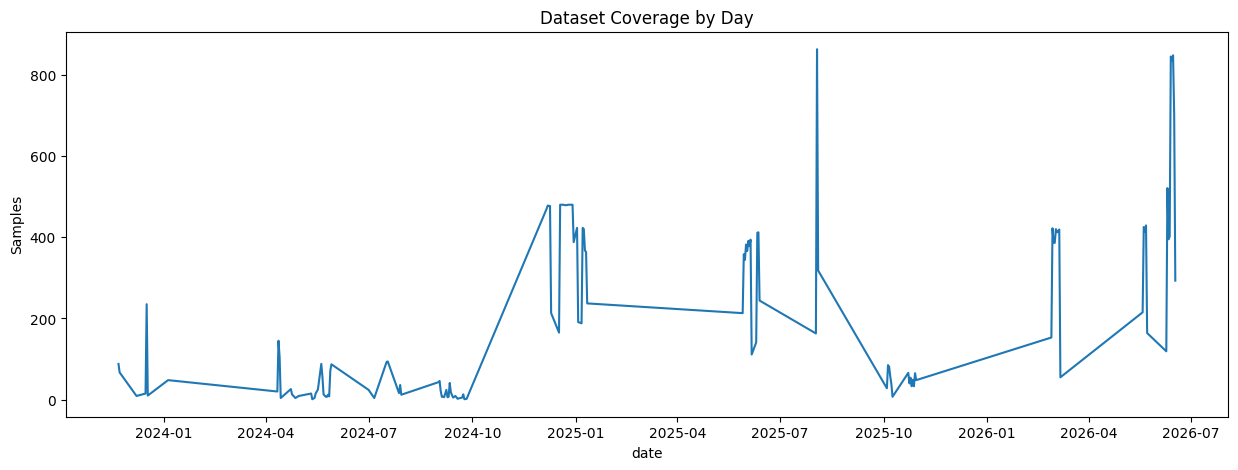

In [41]:
#dataset visualization

import matplotlib.pyplot as plt

daily_samples.plot(
    figsize=(15,5)
)

plt.title(
    "Dataset Coverage by Day"
)

plt.ylabel("Samples")
plt.show()

<Axes: xlabel='month'>

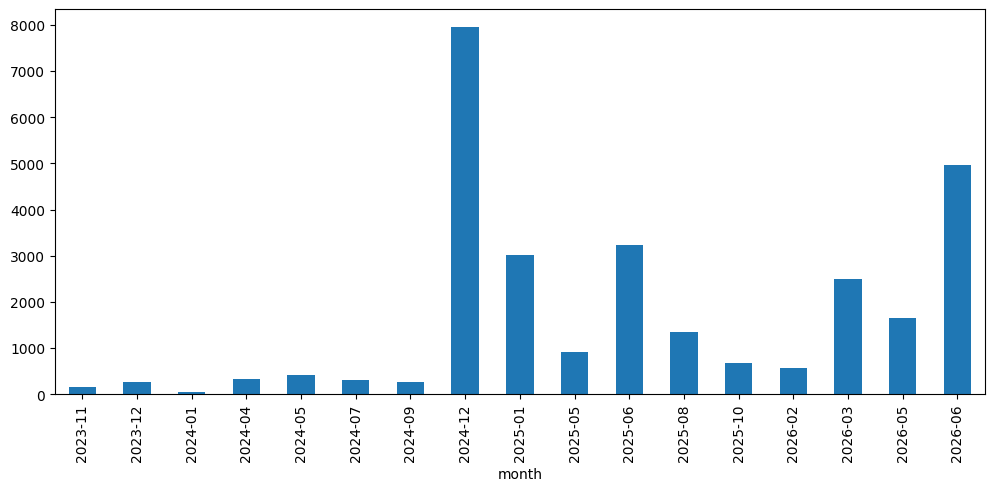

In [42]:
master_df_clean["month"] = pd.to_datetime(
    master_df_clean["timestamp"]
).dt.to_period("M")

monthly_samples = (
    master_df_clean
    .groupby("month")
    .size()
)

monthly_samples.plot(
    kind="bar",
    figsize=(12,5)
)

In [43]:
days_recorded = (
    pd.to_datetime(master_df_clean["timestamp"])
    .dt.date
    .nunique()
)

print(days_recorded)

136
